# Problem 2 - Policy and Value Iteration
---

In [505]:
import numpy as np
import matplotlib.pyplot as plt

## Util methods to represent the grid (do not modify)
#### You do not need modify any of these methods to complete Problem 2

In [506]:
# Maze state is represented as a 2-element NumPy array: (Y, X). Increasing Y is South.
grid = [
    'o.x.u',
    '..y..',
    '..y.*',
    '..z..']
topology = np.array([list(row) for row in grid])
flat_topology = topology.ravel()
rewards = {'.': 0, '*': 50, 'o': 4, 'u': 20, 'x': -10, 'y': -50,'z': -20}

row_count = len(grid) # 4
col_count = len(grid[0]) # 5
shape = (row_count, col_count) # (4, 5)

# Possible actions, expressed as (delta-y, delta-x)
directions="NSEW"
maze_actions = {
    'N': np.array([-1, 0]),
    'S': np.array([1, 0]),
    'E': np.array([0, 1]),
    'W': np.array([0, -1]),
}
actions = [maze_actions[direction] for direction in directions]


# Returns true if pos (y,x) is out of bounds
def is_wall(pos):
    (y, x) = pos
    return (y < 0 or y >= row_count or x < 0 or x >= col_count)

# Input is a flattened state, returns the reward at that state
def get_reward(state):
    assert (state in range(num_states)), f"get_reward: State was not an integer representing an in-bounds state ({state} was given)"
    return rewards.get(flat_topology[int(state)])

# Input is a flattened state, returns the unflattened representation of the state
def unflatten_index(flattened_index):
    return np.unravel_index(flattened_index, shape)

# Input state is an unflattened position and action is an index into the actions[] array
# Returns a tuple containing the new position of taking the action from the state
def move(state, action):
    return tuple((state + actions[action]).reshape(1, -1)[0])

# Returns an array of the "side states" when taking action beginning at unflattened position state
# Does not return states which are out of bounds
def get_side_states(action, state):
    side_states = []
    
    if action == 0 or action == 1:
        if not is_wall(move(state, 3)):
            side_states.append(move(state, 3))
        if not is_wall(move(state, 2)):
            side_states.append(move(state, 2))
    elif action == 2 or action == 3:
        if not is_wall(move(state, 0)):
            side_states.append(move(state, 0))
        if not is_wall(move(state, 1)):
            side_states.append(move(state, 1))
            
    return side_states
    
# Inputs s1, s2 are flattened states, action represents an index into the actions array
# Returns p(s2 | s1, action)
def get_transition_prob(s1, action, s2):
    # Check the inputs are valid
    assert (action in [0,1,2,3]), f"get_transition_prob: Action needs to be an integer in [0,1,2,3], but {action} was given"
    assert (s1 in range(num_states)), f"get_transition_prob: Input s1 was not an integer representing an in-bounds state ({s1} was given)"
    assert (s2 in range(num_states)), f"get_transition_prob: Input s2 was not an integer representing an in-bounds state ({s2} was given)"
    
    state1 = unflatten_index(int(s1))
    state2 = unflatten_index(int(s2))
    action = int(action)

    new_state = move(state1, action)

    sstates = get_side_states(action, state1)
    succeed_prb = 0.8
    slip_prb = 0.1

    # One of the side states was a wall: adjust probabilities accordingly.
    if len(sstates) == 1:
        succeed_prb = 0.9

    if is_wall(new_state):
        if(state1 == state2):
            return succeed_prb
    else:
        if(state2 == new_state):
            return succeed_prb

    # Oherwise, check if state2 is on either side
    for side_state in sstates:
        if(state2 == side_state):
            return slip_prb

    return 0.

In [507]:
# MAKE PLOTS (do not modify)

# Util to draw the value function V as numbers on a plot.
def make_value_plot(V):
    # Useful stats for the plot
    value_function = np.reshape(V, shape)

    # Write the value on top of each square
    indx, indy = np.arange(row_count), np.arange(col_count)

    fig, ax = plt.subplots()
    ax.imshow(value_function, interpolation='none', cmap= plt.get_cmap('coolwarm_r'))

    for s in range(len(V)):
        val = V[s]
        (xval, yval) = unflatten_index(s)
        t = "%.2f"%(val,) # format value with 1 decimal point
        ax.text(yval, xval, t, color='black', va='center', ha='center', size=15)
        

# Util to draw the policy pi as arrows on a plot.
def make_policy_plot(pi, iter_type, iter_num):
    # Useful stats for the plot
    row_count = len(grid)
    col_count = len(grid[0])
    policy_function = np.reshape(pi, shape)

    for row in range(row_count):
        for col in range(col_count):
            if policy_function[row,col] == 0:
                dx = 0; dy = -.5
            if policy_function[row,col] == 1:
                dx = 0; dy = .5
            if policy_function[row,col] == 2:
                dx = .5; dy = 0
            if policy_function[row,col] == 3:
                dx = -.5; dy = 0
            plt.arrow( col , row , dx , dy , shape='full', fc='w' , ec='gray' , lw=1., length_includes_head=True, head_width=.1 )
    plt.title(iter_type + ' Iteration, i = ' + str(iter_num))
    # plt.savefig(iter_type + '_' + str(iter_num) + '.png')
    plt.show()

In [508]:
np.random.seed(181)
VALUE_ITER = 'Value'
POLICY_ITER = 'Policy'

num_states = shape[0] * shape[1] # num_states = 20
num_actions = len(actions) # num_actions = 4

# Problem Description
Below you will implement policy and value iteration.

A state is represented as an integer from ``0`` to ``num_states - 1``
<br>
An action is represented as an integer in ``[0,1,2,3]``, which represents the four cardinal directions [N,S,E,W]

Each state has a reward associated with it. The agent gains the reward of a state when it takes an action at that state, not immediately upon entry.

``pi`` contains the learned policy at each state, represented by an array of length ``num_states``. In this exercise we will be implementing a deterministic policy, so each state has exactly one action associated with it.
<br>
ex: [2, 3, 1, 1, 2, 0, 1, 2, 2, 1, 3, 0, 0, 2, 2, 1, 3, 3, 2, 0]

``V`` represents the learned value function at each state. Like the above, it is also represented as an array of length ``num_states`` where the entry at index ``i`` represents the value of state ``i``.


## Helper methods

Recall that when you take an action in Gridworld, you won't always necessarily move in that direction. Instead there is some probability of moving to a state on either side. You do not need to calculate these transition probabilities yourself. Please use the helper functions ``get_transition_prob`` and ``get_reward`` in this file. The method headers are listed below:

``get_reward(state):`` Input is a state, output is the reward at that state

``get_transition_prob(s1, a, s2):`` Returns the probability of transitioning from state ``s1`` to state ``s2`` upon taking action ``a``.

An example is given below:

In [509]:
# Example usage
print(get_reward(14))
print(get_transition_prob(16, 0, 11))

50
0.8


## 1a) Policy Evaluation

Returns array ``V`` representing the value of policy ``pi`` using discount factor ``gamma``

Note: You can do this either closed-form or iteratively. If performed iteratively, please use a convergence tolerance of at least ``0.0001``

In [510]:
# Solution (iterative)
def policy_evaluation(pi, gamma):
    theta = 0.0001
    # Start with a random (all 0) value function
    V = np.zeros(num_states)
    while True:
        delta = 0.0
        for s in range(num_states):
            a = int(pi[s])
            exp_next_v = sum(
                get_transition_prob(s, a, sp) * V[sp] for sp in range(num_states)
            )
            new_v = get_reward(s) + gamma * exp_next_v
            delta = max(delta, abs(new_v - V[s]))
            V[s] = new_v
        if delta < theta:
            break
    return V

## 1b) Policy Iteration

Now that we have ``V`` computed in 1a), perform **one step** of policy iteration to return the updated policy ``pi_new``

In [511]:
def update_policy_iteration(V, gamma):
    pi_new = np.zeros(num_states)
    for s in range(num_states):
        best_q = -np.inf
        best_a = 0
        for a in range(num_actions):
            exp_next_v = sum(
                get_transition_prob(s, a, sp) * V[sp] for sp in range(num_states)
            )
            q_sa = get_reward(s) + gamma * exp_next_v
            if q_sa > best_q:
                best_q = q_sa
                best_a = a
        pi_new[s] = best_a
    return pi_new

## 2) Value Iteration
Given a value function ``V``, perform **one step** of value iteration and return the updated ``V_new`` and corresponding ``pi_new``

In [512]:
def update_value_iteration(V, gamma):
    V_new = np.zeros(num_states)
    pi_new = np.zeros(num_states)
    for s in range(num_states):
        best_q = -np.inf
        best_a = 0
        for a in range(num_actions):
            exp_next_v = sum(
                get_transition_prob(s, a, sp) * V[sp] for sp in range(num_states)
            )
            q_sa = get_reward(s) + gamma * exp_next_v
            if q_sa > best_q:
                best_q = q_sa
                best_a = a
        V_new[s] = best_q
        pi_new[s] = best_a
    return V_new, pi_new

# Run code, plot results

The ``learn_strategy`` method iteratively runs the one-step methods you wrote in parts 1 and 2, either until the value function converges under <TT>ct</TT> or until a specified number of iterations <TT>max_iter</TT> have elapsed. It will also print out intermediate plots of the learned policy and value function at intervals of <TT>print_every</TT>. The arguments of the function are listed in more detail below:

``planning_type`` (<TT>string</TT>): 
    Specifies whether value or policy iteration is used to learn the strategy.
    
``max_iter`` (<TT>int</TT>):
    The maximum number of iterations (i.e. number of updates) the learning
    policy will be run for.
    
``print_every`` (<TT>int</TT>):
    The frequency at which the function will print value and policy plots.
    
``ct`` (<TT>float</TT>):
    The convergence tolerance used for policy or value iteration.
    
``gamma`` (<TT>float</TT>):
    The discount factor.

In [513]:
# Do not modify the learn_strategy method, but read through its code
def learn_strategy(planning_type = VALUE_ITER, max_iter = 10, print_every = 5, ct = None, gamma = 0.7):
    # Loop over some number of episodes
    V = np.zeros(num_states)
    pi = np.zeros(num_states)

    # Update Q-table using value/policy iteration until max iterations or until ct reached
    for n_iter in range(max_iter):
        V_prev = V.copy()

        # Update V and pi using value or policy iteration.
        if planning_type == VALUE_ITER:
            V, pi = update_value_iteration(V, gamma)
        elif planning_type == POLICY_ITER:
            V = policy_evaluation(pi, gamma)
            pi = update_policy_iteration(V, gamma)
        
        # Calculate the difference between this V and the previous V
        diff = np.absolute(np.subtract(V, V_prev))

        # Check that every state's difference is less than the convergence tol
        if ct and np.max(diff) < ct:
            make_value_plot(V = V)
            make_policy_plot(pi = pi, iter_type = planning_type, iter_num = n_iter+1)
            print("Converged at iteration " + str(n_iter+1))
            return 0

        # Make value plot and plot the policy
        if (n_iter % print_every == 0):
            make_value_plot(V = V)
            make_policy_plot(pi = pi, iter_type = planning_type, iter_num = n_iter+1)

## Show Policy Iteration

Beginning policy iteration.


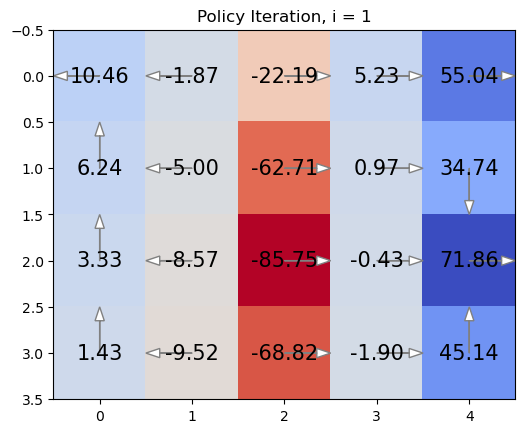

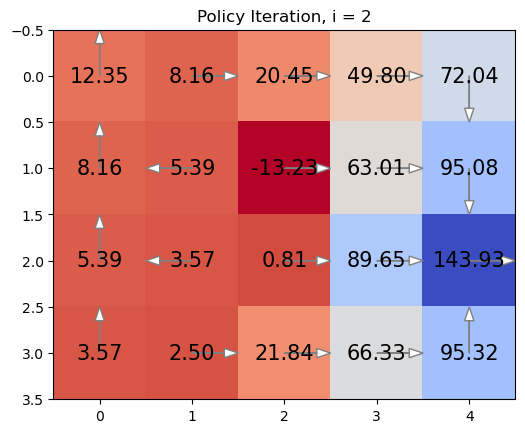

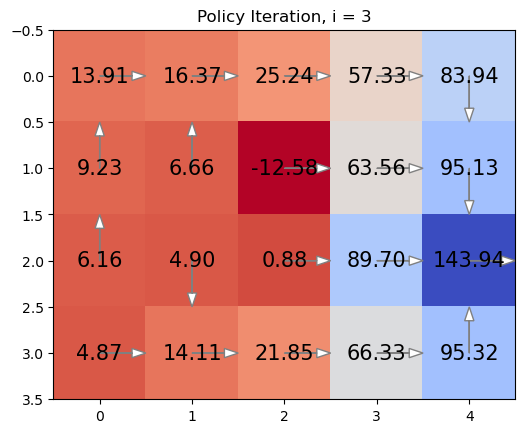

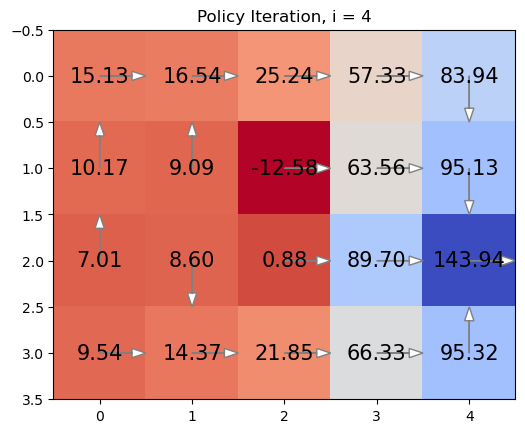

Policy iteration complete.



In [514]:
print('Beginning policy iteration.')
learn_strategy(planning_type=POLICY_ITER, max_iter = 4, print_every = 1, ct = 0.01, gamma = 0.7)
print('Policy iteration complete.\n')

## Show Value Iteration

Beginning value iteration.


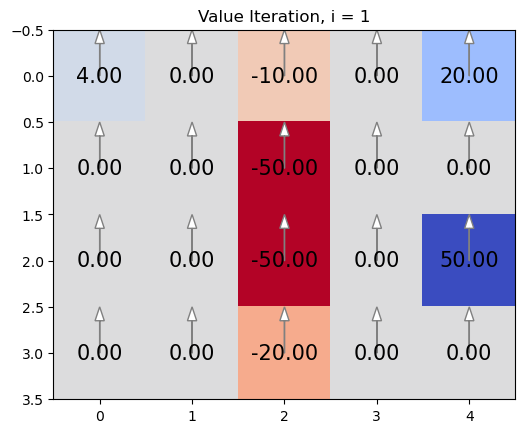

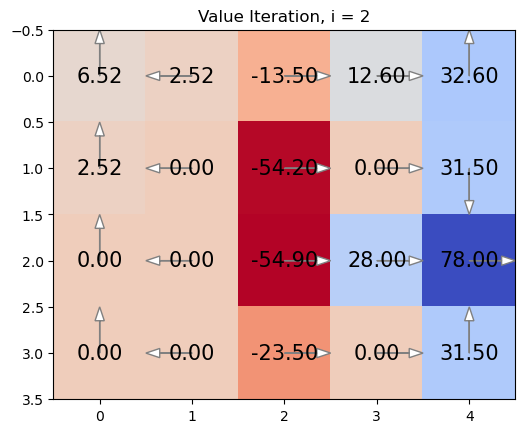

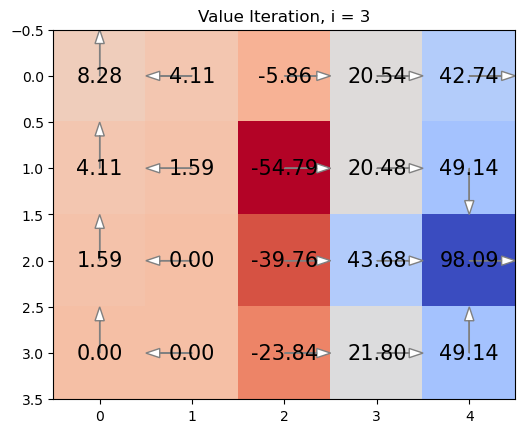

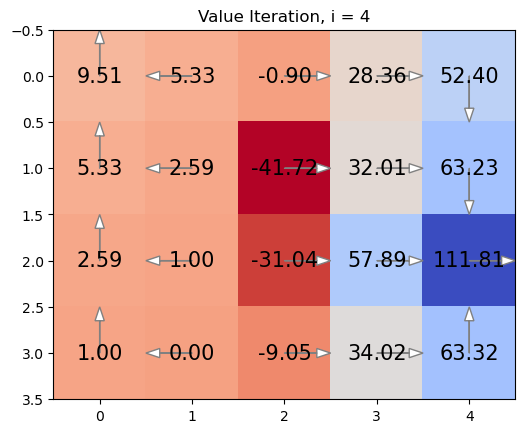

Value iteration complete.



In [515]:
print('Beginning value iteration.')
learn_strategy(planning_type=VALUE_ITER, max_iter = 4, print_every = 1, ct = 0.01, gamma = 0.7)
print('Value iteration complete.\n')

# Problem 3 
---

Make sure to install pygame (i.e. through running `pip install pygame`)

In [516]:
import numpy as np
import numpy.random as npr
import pygame as pg

# Problem 2 fixes the global RNG with np.random.seed(181). SwingyMonkey and
# this learner use the same RNG, so full-notebook runs would replay identically.
np.random.seed(None)

# # uncomment this for animation
# from p3src.SwingyMonkey import SwingyMonkey

# uncomment this for no animation (use this for most purposes! it gets very slow otherwise)
from p3src.SwingyMonkeyNoAnimation import SwingyMonkey

In [517]:
# Some constants. Don't edit this!
X_BINSIZE = 200
Y_BINSIZE = 100
X_SCREEN = 1400
Y_SCREEN = 900

In [518]:
class RandomJumper(object):
    """
    This agent jumps randomly.
    """

    def __init__(self):
        self.last_state = None
        self.last_action = None
        self.last_reward = None

        # We initialize our Q-value grid that has an entry for each action and state.
        # (action, rel_x, rel_y)
        self.Q = np.zeros((2, X_SCREEN // X_BINSIZE, Y_SCREEN // Y_BINSIZE))

    def reset(self):
        self.last_state = None
        self.last_action = None
        self.last_reward = None

    def discretize_state(self, state):
        """
        Discretize the position space to produce binned features.
        rel_x = the binned relative horizontal distance between the monkey and the tree
        rel_y = the binned relative vertical distance between the monkey and the tree
        """

        rel_x = int((state["tree"]["dist"]) // X_BINSIZE)
        rel_y = int((state["tree"]["top"] - state["monkey"]["top"]) // Y_BINSIZE)
        return (rel_x, rel_y)

    def action_callback(self, state):
        """
        Implement this function to learn things and take actions.
        Return 0 if you don't want to jump and 1 if you do.
        """

        new_action = npr.rand() < 0.1
        new_state = state

        self.last_action = new_action
        self.last_state = new_state

        return self.last_action

    def reward_callback(self, reward):
        """This gets called so you can see what reward you get."""

        self.last_reward = reward

In [519]:
class Learner(object):
    '''
    This agent uses Q-learning!
    '''

    def __init__(self):
        self.last_state = None
        self.last_action = None
        self.last_reward = None
        self.alpha = 0.1
        self.epsilon = 0.1
        self.gamma = 0.9
        nx = X_SCREEN // X_BINSIZE
        ny = Y_SCREEN // Y_BINSIZE
        self.Q = np.zeros((2, nx, ny))

    def reset(self):
        self.last_state = None
        self.last_action = None
        self.last_reward = None

    def discretize_state(self, state):
        rel_x = int(state["tree"]["dist"] // X_BINSIZE)
        rel_y = int((state["tree"]["top"] - state["monkey"]["top"]) // Y_BINSIZE)
        nx, ny = self.Q.shape[1], self.Q.shape[2]
        rel_x = int(np.clip(rel_x, 0, nx - 1))
        rel_y = int(np.clip(rel_y, 0, ny - 1))
        return (rel_x, rel_y)

    def action_callback(self, state):
        '''
        Implement this function to learn things and take actions.
        Return 0 if you don't want to jump and 1 if you do.
        '''

        cur = self.discretize_state(state)
        if self.last_state is not None and self.last_reward is not None:
            lx, ly = self.last_state
            cx, cy = cur
            q_max_next = max(self.Q[0, cx, cy], self.Q[1, cx, cy])
            old = self.Q[self.last_action, lx, ly]
            td_target = self.last_reward + self.gamma * q_max_next
            self.Q[self.last_action, lx, ly] = old + self.alpha * (td_target - old)

        if npr.rand() < self.epsilon:
            new_action = int(npr.choice([0, 1]))
        else:
            q0 = self.Q[0, cur[0], cur[1]]
            q1 = self.Q[1, cur[0], cur[1]]
            new_action = 0 if q0 >= q1 else 1

        self.last_state = cur
        self.last_action = new_action
        self.last_reward = None
        return new_action

    def reward_callback(self, reward):
        '''This gets called so you can see what reward you get.'''

        self.last_reward = reward

In [520]:
### more advanced agent, don't need this for full credit
class GravityLearner(object):
    '''
    This agent uses Q-learning and infers gravity!
    '''

    def __init__(self):
        self.last_state  = None
        self.last_action = None
        self.last_reward = None

        # Q-learning parameters
        self.alpha = 0.1
        self.epsilon = 0.001
        self.gamma = 0.9

        # Gravity parameters
        self.gravity = None
        self.first_timestep = True

        # We initialize our Q-value grid that has an entry for each action and state.
        # (action, rel_x, rel_y)
        self.Q = np.zeros((2, X_SCREEN // X_BINSIZE, Y_SCREEN // Y_BINSIZE, 5))

    def reset(self):
        self.last_state  = None
        self.last_action = None
        self.last_reward = None

        # Gravity parameters
        self.gravity = None
        self.first_timestep = True

    def discretize_state(self, state, gravity):
        '''
        Discretize the position space to produce binned features.
        rel_x = the binned relative horizontal distance between the monkey and the tree
        rel_y = the binned relative vertical distance between the monkey and the tree        
        '''

        rel_x = int((state["tree"]["dist"]) // X_BINSIZE)
        rel_y = int((state["tree"]["top"] - state["monkey"]["top"]) // Y_BINSIZE)
        return (rel_x, rel_y, self.gravity) 

    def update_gravity(self, state):
        '''
        Use the first timestep to determine the epoch's 'gravity'.
        Returns True if gravity has been updated, False otherwise. 
        '''

        # Check that the monkey has moved.
        if self.first_timestep or (self.gravity == None and self.first_state['monkey']['top'] == state['monkey']['top']):
            self.first_timestep = False
            self.first_state = state
            self.last_action = 0
            return False
        
        # Set gravity as the distance the monkey falls in the first timestep.
        elif self.gravity is None:
            self.gravity = int(self.first_state['monkey']['top'] - state['monkey']['top'])
        
        return True

    def action_callback(self, state):
        '''
        Implement this function to learn things and take actions.
        Return 0 if you don't want to jump and 1 if you do.
        '''

        # Continue if gravity has been updated.
        if self.update_gravity(state):

            # Discretize 'state' to get your transformed 'current state' features.
            cur_state = self.discretize_state(state, self.gravity)

            # Perform the Q-Learning update using 'current state' and the 'last state'.
            Q_sa = (self.Q[0][cur_state], self.Q[1][cur_state])
            self.Q[self.last_action][self.last_state] = ((1-self.alpha) * self.Q[self.last_action][self.last_state] 
                                                           + self.alpha * (self.last_reward + self.gamma * np.max(Q_sa)))

            # Choose the next action using an epsilon-greedy policy.
            if npr.rand() < self.epsilon:
                self.last_action = npr.choice([0,1])
            else:
                self.last_action = np.argmax(Q_sa)

            self.last_state = cur_state

        return self.last_action

    
    def reward_callback(self, reward):
        '''This gets called so you can see what reward you get.'''

        self.last_reward = reward

In [521]:
def run_games(learner, hist, iters=100, t_len=100):
    """
    Driver function to simulate learning by having the agent play a sequence of games.
    """
    for ii in range(iters):
        # Make a new monkey object.
        swing = SwingyMonkey(sound=False,  # Don't play sounds.
                             text="Epoch %d" % (ii),  # Display the epoch on screen.
                             tick_length=t_len,  # Make game ticks super fast.
                             action_callback=learner.action_callback,
                             reward_callback=learner.reward_callback)

        # Loop until you hit something.
        while swing.game_loop():
            pass

        # Save score history.
        hist.append(swing.score)

        # Reset the state of the learner.
        learner.reset()
    pg.quit()
    return

In [573]:
# Uncomment the agent you want to run.
# agent = RandomJumper()
agent = Learner()
# agent = GravityLearner()

# Empty list to save history.
hist = []

# Run games. You can update t_len to be smaller to run it faster.
run_games(agent, hist, 100, 100)
print(hist)

# Save history. 
np.save('hist', np.array(hist))

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 0, 0, 0, 0, 1, 0, 0, 0, 3, 0, 5, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 4, 4, 0, 3, 1, 1, 0, 0, 0, 4, 1, 5, 5, 0, 6, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 7, 0, 0, 2, 0, 0, 1, 6, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 4, 2, 2]


In [ ]:
# Plot score vs epoch for the write-up (saves next to hw6_release.tex)
import os
import matplotlib.pyplot as plt

os.makedirs("img_output", exist_ok=True)
h = np.array(hist)
if h.size == 0 and os.path.isfile("hist.npy"):
    h = np.load("hist.npy")
plt.figure(figsize=(8, 3))
plt.plot(np.arange(len(h)), h, ".-", markersize=3)
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Swingy Monkey: score per epoch")
plt.tight_layout()
plt.savefig("img_output/swingy_hist.pdf")
plt.savefig("img_output/swingy_hist.png")
plt.show()